# 1. Setup & Load Hasil

---



In [14]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

BASE_PATH    = '/content/drive/MyDrive/stock_prediction-lstm-tft'
LSTM_PATH    = f'{BASE_PATH}/04_model/lstm'
TFT_PATH     = f'{BASE_PATH}/04_model/tft'
RESULTS_PATH = f'{BASE_PATH}/05_results'

os.makedirs(f'{RESULTS_PATH}/figures', exist_ok=True)

# Load hasil LSTM
with open(f'{LSTM_PATH}/lstm_results.pkl', 'rb') as f:
    lstm_results = pickle.load(f)

# Load hasil TFT
with open(f'{TFT_PATH}/tft_results.pkl', 'rb') as f:
    tft_results = pickle.load(f)

symbols = list(lstm_results.keys())
print("Saham:", symbols)
print("LSTM results loaded")
print("TFT results loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saham: ['ASII.JK', 'BBCA.JK', 'ICBP.JK', 'TLKM.JK', 'UNVR.JK']
LSTM results loaded
TFT results loaded


## 2. Tabel Perbandingan Metrik
Perbandingan performa LSTM dan TFT berdasarkan metrik RMSE, MAE, MAPE, dan R².

---



In [15]:
# Tabel LSTM per saham
lstm_rows = []
for symbol in symbols:
    lstm_rows.append({
        'Saham': symbol,
        'Model': 'LSTM',
        'RMSE': lstm_results[symbol]['RMSE'],
        'MAE':  lstm_results[symbol]['MAE'],
        'MAPE': lstm_results[symbol]['MAPE'],
        'R2':   lstm_results[symbol]['R2']
    })

# Tabel TFT (agregat)
tft_row = {
    'Saham': 'All',
    'Model': 'TFT',
    'RMSE': tft_results['RMSE'],
    'MAE':  tft_results['MAE'],
    'MAPE': tft_results['MAPE'],
    'R2':   tft_results['R2']
}

df_lstm = pd.DataFrame(lstm_rows)
df_tft  = pd.DataFrame([tft_row])

print("=== Hasil LSTM per Saham ===")
print(df_lstm.to_string(index=False))
print("\n=== Hasil TFT (Agregat) ===")
print(df_tft.to_string(index=False))

# Rata-rata LSTM
print("\n=== Rata-rata LSTM ===")
print(f"RMSE : {df_lstm['RMSE'].mean():.4f}")
print(f"MAE  : {df_lstm['MAE'].mean():.4f}")
print(f"MAPE : {df_lstm['MAPE'].mean():.2f}%")
print(f"R2   : {df_lstm['R2'].mean():.4f}")

=== Hasil LSTM per Saham ===
  Saham Model     RMSE      MAE      MAPE       R2
ASII.JK  LSTM 0.030317 0.022433  3.309455 0.973443
BBCA.JK  LSTM 0.031321 0.024512  3.657090 0.808002
ICBP.JK  LSTM 0.041387 0.031503  6.359009 0.924916
TLKM.JK  LSTM 0.060855 0.047773 11.972764 0.924992
UNVR.JK  LSTM 0.022694 0.014933 29.518254 0.922547

=== Hasil TFT (Agregat) ===
Saham Model     RMSE      MAE     MAPE       R2
  All   TFT 0.044815 0.030491 7.447975 0.969485

=== Rata-rata LSTM ===
RMSE : 0.0373
MAE  : 0.0282
MAPE : 10.96%
R2   : 0.9108


## 3. Visualisasi Perbandingan Metrik

---



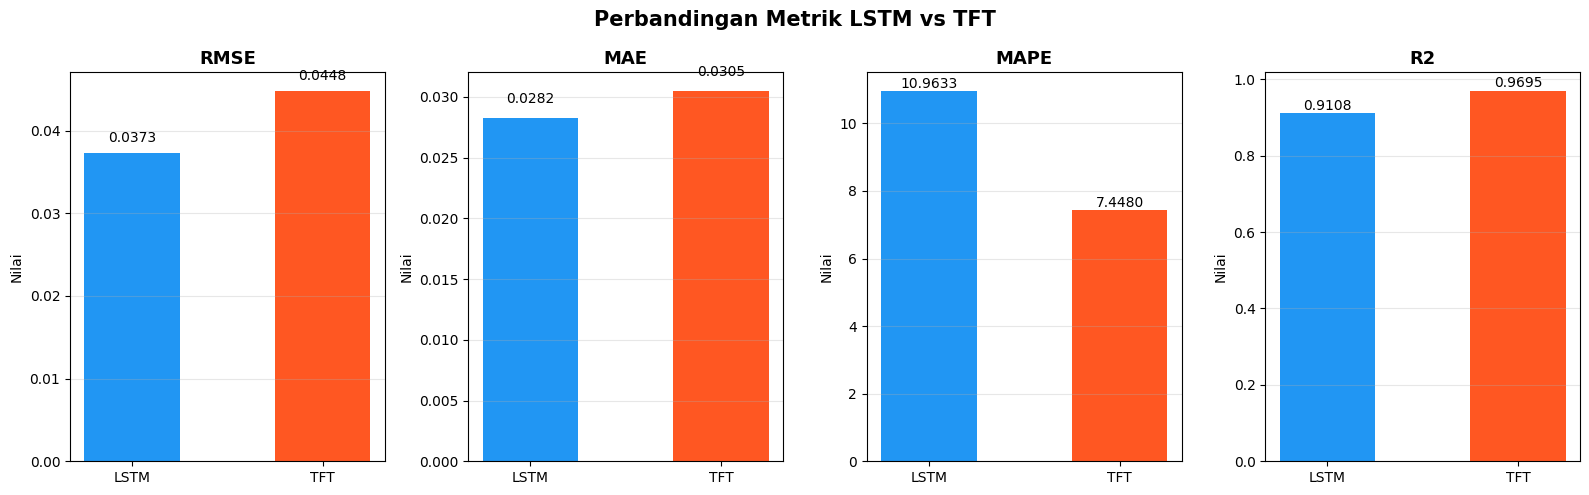

In [17]:
metrics = ['RMSE', 'MAE', 'MAPE', 'R2']
lstm_avg = [df_lstm['RMSE'].mean(), df_lstm['MAE'].mean(),
            df_lstm['MAPE'].mean(), df_lstm['R2'].mean()]
tft_vals = [tft_results['RMSE'], tft_results['MAE'],
            tft_results['MAPE'], tft_results['R2']]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, metric in enumerate(metrics):
    bars = axes[i].bar(['LSTM', 'TFT'], [lstm_avg[i], tft_vals[i]],
                        color=['#2196F3', '#FF5722'], width=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Nilai')
    axes[i].grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars, [lstm_avg[i], tft_vals[i]]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Metrik LSTM vs TFT', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/figures/comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Visualisasi Perbandingan Prediksi vs Aktual

---



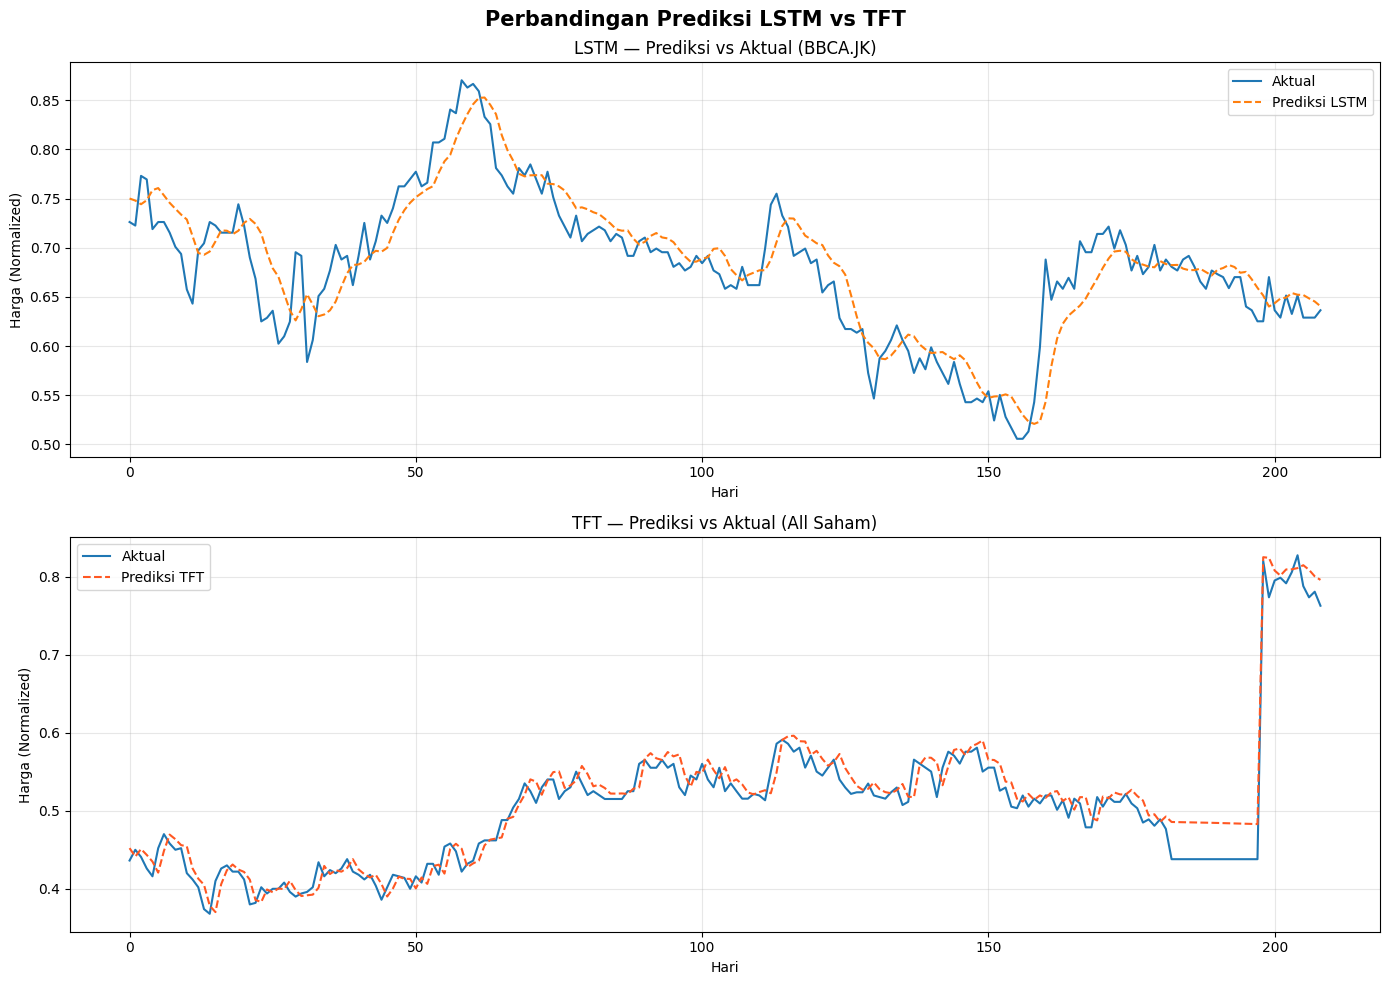

In [18]:
y_test_tft = tft_results['y_test']
y_pred_tft = tft_results['y_pred']

# Ambil salah satu saham LSTM untuk dibandingkan (BBCA)
y_test_lstm = lstm_results['BBCA.JK']['y_test']
y_pred_lstm = lstm_results['BBCA.JK']['y_pred']

# Sesuaikan panjang
min_len = min(len(y_test_tft), len(y_test_lstm))
y_test_tft  = y_test_tft[:min_len]
y_pred_tft  = y_pred_tft[:min_len]
y_test_lstm = y_test_lstm[:min_len]
y_pred_lstm = y_pred_lstm[:min_len]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(y_test_lstm, label='Aktual', linewidth=1.5)
axes[0].plot(y_pred_lstm, label='Prediksi LSTM', linewidth=1.5, linestyle='--')
axes[0].set_title('LSTM — Prediksi vs Aktual (BBCA.JK)')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Harga (Normalized)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_test_tft, label='Aktual', linewidth=1.5)
axes[1].plot(y_pred_tft, label='Prediksi TFT', linewidth=1.5, linestyle='--', color='#FF5722')
axes[1].set_title('TFT — Prediksi vs Aktual (All Saham)')
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Harga (Normalized)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Prediksi LSTM vs TFT', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/figures/comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Kesimpulan Evaluasi
Berdasarkan hasil perbandingan metrik antara model LSTM dan TFT:
- Model dengan MAPE lebih rendah menunjukkan akurasi prediksi yang lebih baik
- Model dengan R² lebih tinggi menunjukkan kemampuan yang lebih baik dalam
  menjelaskan variansi data

In [21]:
print("=== KESIMPULAN ===")
print(f"LSTM rata-rata MAPE : {df_lstm['MAPE'].mean():.2f}%")
print(f"TFT MAPE            : {tft_results['MAPE']:.2f}%")
print(f"LSTM rata-rata R²   : {df_lstm['R2'].mean():.4f}")
print(f"TFT R²              : {tft_results['R2']:.4f}")

if tft_results['MAPE'] < df_lstm['MAPE'].mean():
    print("\nTFT lebih unggul dari LSTM berdasarkan MAPE")
else:
    print("\nLSTM lebih unggul dari TFT berdasarkan MAPE")

if tft_results['R2'] > df_lstm['R2'].mean():
    print("TFT lebih unggul dari LSTM berdasarkan R²")
else:
    print("LSTM lebih unggul dari TFT berdasarkan R²")

=== KESIMPULAN ===
LSTM rata-rata MAPE : 10.96%
TFT MAPE            : 7.45%
LSTM rata-rata R²   : 0.9108
TFT R²              : 0.9695

TFT lebih unggul dari LSTM berdasarkan MAPE
TFT lebih unggul dari LSTM berdasarkan R²
